In [1]:
import kagglehub
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray

path = str(kagglehub.dataset_download("icebearogo/fruit-classification-dataset")) + "/Fruit_dataset"
print("Path to dataset files:", path)
csv_path = f"{path}/train.csv"
df = pd.read_csv(csv_path)

print(df.head())

# load csv
train_df = pd.read_csv(f"{path}/train.csv")
val_df = pd.read_csv(f"{path}/val.csv")
test_df = pd.read_csv(f"{path}/test.csv")





def load_color_hog(csv_df, base_path, target_size=(64,64)):
    features, labels = [], []

    for _, row in csv_df.iterrows():
        fname = row["image:FILE"].replace("train/", "train1/").replace("val/", "val1/").replace("test/", "test1/").lstrip("/\\")
        file = os.path.join(base_path, fname)

        # load in color (RGB)
        img = Image.open(file).convert("RGB")
        
        # crop to center square
        width, height = img.size
        min_dim = min(width, height)
        left = (width - min_dim) // 2
        top = (height - min_dim) // 2
        img = img.crop((left, top, left + min_dim, top + min_dim))
        
        # resize
        img = img.resize(target_size)
        arr = np.array(img)

        # convert to grayscale for HOG
        gray = rgb2gray(arr)

        # extract HOG features
        hog_feats = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        features.append(hog_feats)
        labels.append(row["category"])
    
    return np.array(features), np.array(labels)

# usage
X_train, y_train = load_color_hog(train_df, path)
X_val, y_val     = load_color_hog(val_df, path)



print("Train:", X_train.shape, "Val:", X_val.shape)
print("Unique train labels:", np.unique(y_train))
print("Unique val labels:", np.unique(y_val))

/media/systems/Data/Uni/(PRML) - Pattern Recognition and Machine Learning/PRML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-27 11:23:31.788230: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-27 11:23:31.811433: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-27 11:23:32.925653: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, i

Path to dataset files: /home/systems/.cache/kagglehub/datasets/icebearogo/fruit-classification-dataset/versions/1/Fruit_dataset
               image:FILE  category
0   train/oil_palm/57.jpg         0
1  train/oil_palm/881.jpg         0
2  train/oil_palm/450.jpg         0
3   train/oil_palm/28.jpg         0
4   train/oil_palm/62.jpg         0
Train: (40000, 1764) Val: (5000, 1764)
Unique train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
Unique val labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 

In [6]:
from matplotlib import pyplot as plt



# Show first 5 images
for i in range(5):
    plt.imshow(X_train[i].reshape(64,64), cmap='gray')
    plt.title(y_train[i])
    plt.show()




ValueError: cannot reshape array of size 1764 into shape (64,64)

In [16]:
from sklearn.decomposition import PCA
pca = PCA(n_components=150, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
print("Original shape:", X_train.shape, "Reduced shape:", X_train_pca.shape)

Original shape: (40000, 1024) Reduced shape: (40000, 150)


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_train)

print("RF + HOG Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


ValueError: Found input variables with inconsistent numbers of samples: [5000, 40000]

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,      # number of trees (you can bump to 500 if time allows)
    max_depth=None,        # let trees grow fully
    n_jobs=-1,             # use all CPU cores
    random_state=42,
    class_weight="balanced_subsample"  # helps if classes are unbalanced
)


rf.fit(X_train_pca, y_train)

# Validate
y_pred = rf.predict(X_val_pca)
print("Random Forest + PCA Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Random Forest + PCA Accuracy: 0.2488
              precision    recall  f1-score   support

           0       0.06      0.10      0.07        50
           1       0.38      0.30      0.34        50
           2       0.14      0.22      0.17        50
           3       0.14      0.12      0.13        50
           4       0.15      0.16      0.16        50
           5       0.21      0.28      0.24        50
           6       0.33      0.32      0.32        50
           7       0.15      0.16      0.15        50
           8       0.34      0.28      0.31        50
           9       0.33      0.32      0.33        50
          10       0.14      0.16      0.15        50
          11       0.10      0.18      0.13        50
          12       0.24      0.44      0.31        50
          13       0.13      0.44      0.20        50
          14       0.10      0.08      0.09        50
          15       0.17      0.26      0.20        50
          16       0.12      0.10      0.11 

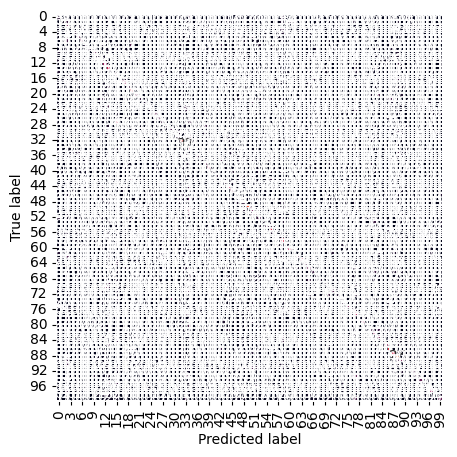

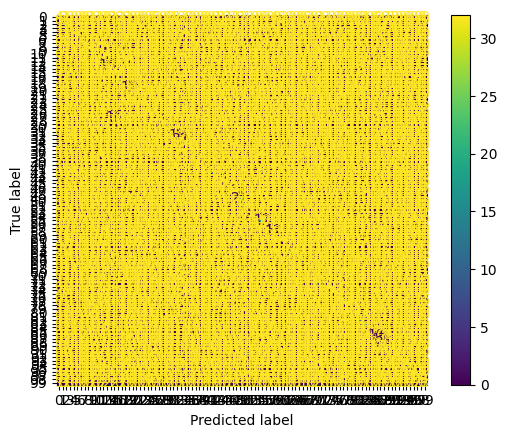

In [12]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
# Compute confusion matrix 
mat = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
# Visualise the confusion matrix using a heatmap
sns.heatmap(mat, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')

# You can also use ConfusionMatrixDisplay
_ = ConfusionMatrixDisplay.from_estimator(model, X_val, y_val)